# 公式チュートリアル 06 — How to Solve ODEs with Rate Law Functions
> 出典: https://ecell4.e-cell.org/tutorials/tutorial06.html

反応速度に**任意の式（rate law）**を与えられる。質量作用でない Michaelis-Menten や、
`~x > x | <式>` の形で連立 ODE をそのまま書ける。

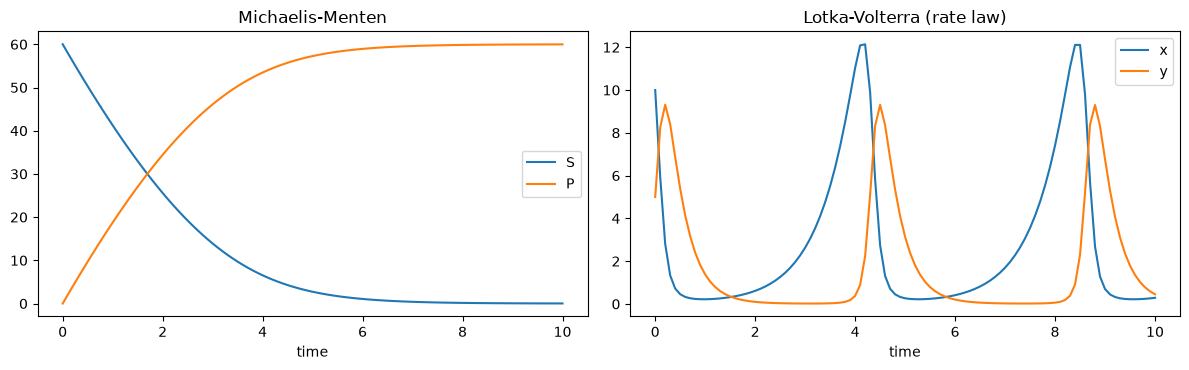

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

# Michaelis-Menten: 速度 = Vmax·E·S/(Km+S)
with reaction_rules():
    S > P | 1.0 * E * S / (30.0 + S)
m1 = get_model()
a = run_simulation(10.0, model=m1, y0={'S': 60, 'E': 30}, species_list=['S','P']).as_array()

# Lotka-Volterra 風の連立 ODE を rate law で
A_,B_,C_,D_ = 1.5, 1.0, 3.0, 1.0
with reaction_rules():
    ~x > x | A_ * x - B_ * x * y
    ~y > y | -C_ * y + D_ * x * y
b = run_simulation(10, model=get_model(), y0={'x': 10, 'y': 5}, species_list=['x','y']).as_array()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.plot(a[:,0], a[:,1], label='S'); ax1.plot(a[:,0], a[:,2], label='P'); ax1.set_title('Michaelis-Menten'); ax1.legend(); ax1.set_xlabel('time')
ax2.plot(b[:,0], b[:,1], label='x'); ax2.plot(b[:,0], b[:,2], label='y'); ax2.set_title('Lotka-Volterra (rate law)'); ax2.legend(); ax2.set_xlabel('time')
plt.tight_layout(); plt.show()

**要点**: `S > P | 式` の右辺に E, S を含む式を書けば非線形速度になる（MM は基質飽和で頭打ち）。
より低レベルには `ReactionRuleDescriptorMassAction`（係数指定）や `ReactionRuleDescriptorPyfunc`（Python 関数）で
速度則を定義することもできる:

```python
def ratelaw(r, p, v, t, rc, pc):
    return 1.0 * r[0] * r[1] - 2.0 * p[0]
desc = ReactionRuleDescriptorPyfunc(ratelaw, 'test')
desc.set_reactant_coefficients([1, 1]); desc.set_product_coefficients([1])
rr.set_descriptor(desc)
```